In [1]:
%env DB_PASSWORD=5J8DhII0RRsPW1

env: DB_PASSWORD=5J8DhII0RRsPW1


In [2]:
import pandas as pd
import re
from constants.db_connections import ENGINE_READ_ONLY
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


pd.reset_option('display.float_format')

In [3]:
# Set your server details
hostname = 'dandyweb01fl'  # Replace with your server's IP or hostname
port = 22                       # Usually 22 for SSH
username = 'glj523'      # Replace with your username
password = 'Wtcantfw36c!123'      # Replace with your password
# Create an SSH client
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

In [4]:

#TODO: Replace with new data
remote_directories = ['/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Kurt',
                      '/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Thorfinn',
                      '/datasets/caeg_fastq/2024/20240702_A00706_0862_BH5F5KDSX7_WBDQ4_new/ssDNALib0019']

lib_ids_all = {}

remote_directory = remote_directories[0]  # Replace with the directory you want to list

command = lambda lib_id: f"zcat /projects/caeg/data/production/*/*/*/{lib_id}/*/stats/metadmg/aggregate/* | head -n 2 | cut -d$'\t' -f1-6"

try:
    # Connect to the server
    ssh.connect(hostname, port, username, password)

    # Run the command to list files and directories

    for dir in remote_directories:
    
        stdin, stdout, stderr = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$'")

        _, test, _ = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$' | wc -l")

        # Process the output
        file_names = stdout.read().decode().splitlines()
        test = test.read().decode()

        lib_ids = [file_name.split("-")[0] for file_name in file_names]

        if int(test) != len(lib_ids):
            raise Exception("Error")

        lib_ids_all[dir.split("/")[-1]] = list(set(lib_ids))
            
        # Print the first 8 letters of each file/directory name
   

except Exception as e:
    raise Exception()

finally:
    # Close the connection
    ssh.close()

df_orig = pd.read_sql(sql='select * from test_1.mega_table_qc_split_mat', con=ENGINE_READ_ONLY)
# abi_data = pd.read_csv(r"c:\Users\glj523\Downloads\CambodiaLibs - cambodia_libs.tsv", sep="\t")

fake_data_1 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)
fake_data_2 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)
fake_data_3 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)

In [5]:
def generate_similar_datasets(n_libraries=40, samples_per_library=4):
    datasets = []
    
    for dataset_num in range(3):
        data = []
        for i in range(n_libraries):
            library_id = f"LV{7008000000 + np.random.randint(0, 999999):09d}"
            
            # Base values for this library
            base_raw_sequences = np.random.randint(40000000, 110000000)
            base_trimmed_ratio = np.random.uniform(0.1, 0.2)  # 10-20% of raw sequences
            base_raw_gc = np.random.randint(48, 55)
            gc_shift = np.random.randint(-2, 4)  # GC content shift after trimming
            
            for j in range(samples_per_library):
                # Add some variation to the base values
                raw_sequences = int(base_raw_sequences * np.random.uniform(0.98, 1.02))
                trimmed_sequences = int(raw_sequences * base_trimmed_ratio * np.random.uniform(0.98, 1.02))
                raw_gc = base_raw_gc
                trimmed_gc = base_raw_gc + gc_shift
                
                data.append({
                    'library_id': library_id,
                    'fastqc_raw__Total Sequences': raw_sequences,
                    'fastqc_trimmed__Total Sequences': trimmed_sequences,
                    'fastqc_raw__%GC': raw_gc,
                    'fastqc_trimmed__%GC': trimmed_gc,
                    'fastp__insert_size': '',
                    'samtools_stats__reads_mapped': ''
                })
        
        df = pd.DataFrame(data)
        df.index = range(len(df))
        datasets.append(df)
    
    return datasets

In [6]:
#TODO: Replace with new data
kurt = lib_ids_all["eDNALib060-Kurt"]
thorf = lib_ids_all["eDNALib060-Thorfinn"]
n6_ss_libs = lib_ids_all["ssDNALib0019"]

include_controls = False  # This will determine if the controls are included in the data or not.
controls_kurt = ["LV7009026112"]
controls_thorfinn = ["LV7009026519", "LV7009026511", "LV7009026461", "LV7009026448"]
controls_sslib = ["LV7009026399", "LV7009026337", "LV7008960913"]

if not include_controls:
    kurt = list(set(kurt) - set(controls_kurt))
    thorf = list(set(thorf) - set(controls_thorfinn))
    n6_ss_libs = list(set(n6_ss_libs) - set(controls_sslib))

n6_ss_libs = [ele for ele in n6_ss_libs if not ele.startswith("Undetermined_")]
n6_ds_libs = [ele for ele in kurt + thorf if not ele.startswith("Undetermined_")]
nx_ss_libs = fake_data_1["library_id"].unique()
nx_ds_libs = fake_data_2["library_id"].unique()

#  Extract the relevant rows and columns 
n6_ss_qc = df_orig[df_orig["library_id"].isin(n6_ss_libs)]
n6_ds_qc = df_orig[df_orig["library_id"].isin(n6_ds_libs)]
nx_ss_qc = df_orig[df_orig["library_id"].isin(nx_ss_libs)]
nx_ds_qc = df_orig[df_orig["library_id"].isin(nx_ds_libs)]

data_template = lambda platform, protocol, df: {'Platform': platform, 'Protocol': protocol, 'df': df}

sequencer_1 = "NovaSeq6"
sequencer_2 = "NovaSeqX"

datasets = [
    data_template(sequencer_1, "Double", n6_ds_qc),
    data_template(sequencer_1, "Single", n6_ss_qc),
    data_template(sequencer_2, "Double", nx_ds_qc),
    data_template(sequencer_2, "Single", nx_ss_qc),
]

get_dataset = {
    "MiSeq_Double": datasets[0],
    "MiSeq_Single": datasets[1],
    "NovaSeq_Double": datasets[2],
    "NovaSeq_Single": datasets[3] 
    }


if len(nx_ds_libs) != len(nx_ds_qc['library_id'].unique()):
    raise Exception()

if len(n6_ss_libs) != len(n6_ss_qc['library_id'].unique()):
    raise Exception()

if len(nx_ss_libs) != len(nx_ss_qc['library_id'].unique()):
    raise Exception()

if len(n6_ds_libs) != len(n6_ds_qc['library_id'].unique()):
    raise Exception()

for data in datasets:
    if data["df"]["sample_name"].duplicated().sum() != 0:
        raise Exception("Duplicate sample names found.")
    if (data["df"]["library_id"] + "_" + data["df"]["qc_type"]).duplicated().sum() != 0:
        raise Exception("Duplicate library IDs and QC types found.")

qc_types_raw = ['L001_R1', 'L002_R1', 'L003_R1', 'L004_R1', 'L001_R2', 'L002_R2', 'L003_R2', 'L004_R2']
qc_types_collapsed = ['L001_collapsed', 'L002_collapsed', 'L003_collapsed','L004_collapsed']
qc_types_singleton = ['L001_singleton', 'L002_singleton', 'L003_singleton', 'L004_singleton']

qc_types_active = qc_types_raw



In [ ]:
command = lambda lib_id: f"zcat /projects/caeg/data/production/*/*/*/{lib_id}/*/stats/metadmg/aggregate/* | head -n 2 | cut -d$'\t' -f1-11"
agg_cols = ['library_id', 'Platform', 'Protocol', 'taxid', 'name', 'rank', 'nalign', 'nreads', 'mean_rlen', 'var_rlen', 'mean_gc', 'var_gc', 'lca', 'taxa_path', 'A', 'q', 'c', 'phi', 'llh', 'ncall', 'sigmaD', 'Zfit', 'A_b', 'q_b', 'c_b', 'phi_b', 'A_CI_l', 'A_CI_h', 'q_CI_l', 'q_CI_h', 'c_CI_l', 'c_CI_h', 'phi_CI_l', 'phi_CI_h', 'fwK0', 'fwN0', 'fwf0', 'fwdx0', 'fwdxConf0', 'fwK1', 'fwN1', 'fwf1', 'fwdx1', 'fwdxConf1', 'fwK2', 'fwN2', 'fwf2', 'fwdx2', 'fwdxConf2', 'fwK3', 'fwN3', 'fwf3', 'fwdx3', 'fwdxConf3', 'fwK4', 'fwN4', 'fwf4', 'fwdx4', 'fwdxConf4', 'fwK5', 'fwN5', 'fwf5', 'fwdx5', 'fwdxConf5', 'fwK6', 'fwN6', 'fwf6', 'fwdx6', 'fwdxConf6', 'fwK7', 'fwN7', 'fwf7', 'fwdx7', 'fwdxConf7', 'fwK8', 'fwN8', 'fwf8', 'fwdx8', 'fwdxConf8', 'fwK9', 'fwN9', 'fwf9', 'fwdx9', 'fwdxConf9', 'fwK10', 'fwN10', 'fwf10', 'fwdx10', 'fwdxConf10', 'fwK11', 'fwN11', 'fwf11', 'fwdx11', 'fwdxConf11', 'fwK12', 'fwN12', 'fwf12', 'fwdx12', 'fwdxConf12', 'fwK13', 'fwN13', 'fwf13', 'fwdx13', 'fwdxConf13', 'fwK14', 'fwN14', 'fwf14', 'fwdx14', 'fwdxConf14', 'fwK15', 'fwN15', 'fwf15', 'fwdx15', 'fwdxConf15', 'fwK16', 'fwN16', 'fwf16', 'fwdx16', 'fwdxConf16', 'fwK17', 'fwN17', 'fwf17', 'fwdx17', 'fwdxConf17', 'fwK18', 'fwN18', 'fwf18', 'fwdx18', 'fwdxConf18', 'fwK19', 'fwN19', 'fwf19', 'fwdx19', 'fwdxConf19', 'fwK20', 'fwN20', 'fwf20', 'fwdx20', 'fwdxConf20', 'fwK21', 'fwN21', 'fwf21', 'fwdx21', 'fwdxConf21', 'fwK22', 'fwN22', 'fwf22', 'fwdx22', 'fwdxConf22', 'fwK23', 'fwN23', 'fwf23', 'fwdx23', 'fwdxConf23', 'fwK24', 'fwN24', 'fwf24', 'fwdx24', 'fwdxConf24', 'fwK25', 'fwN25', 'fwf25', 'fwdx25', 'fwdxConf25', 'fwK26', 'fwN26', 'fwf26', 'fwdx26', 'fwdxConf26', 'fwK27', 'fwN27', 'fwf27', 'fwdx27', 'fwdxConf27', 'fwK28', 'fwN28', 'fwf28', 'fwdx28', 'fwdxConf28', 'fwK29', 'fwN29', 'fwf29', 'fwdx29', 'fwdxConf29', 'bwK0', 'bwN0', 'bwf0', 'bwdx0', 'bwdxConf0', 'bwK1', 'bwN1', 'bwf1', 'bwdx1', 'bwdxConf1', 'bwK2', 'bwN2', 'bwf2', 'bwdx2', 'bwdxConf2', 'bwK3', 'bwN3', 'bwf3', 'bwdx3', 'bwdxConf3', 'bwK4', 'bwN4', 'bwf4', 'bwdx4', 'bwdxConf4', 'bwK5', 'bwN5', 'bwf5', 'bwdx5', 'bwdxConf5', 'bwK6', 'bwN6', 'bwf6', 'bwdx6', 'bwdxConf6', 'bwK7', 'bwN7', 'bwf7', 'bwdx7', 'bwdxConf7', 'bwK8', 'bwN8', 'bwf8', 'bwdx8', 'bwdxConf8', 'bwK9', 'bwN9', 'bwf9', 'bwdx9', 'bwdxConf9', 'bwK10', 'bwN10', 'bwf10', 'bwdx10', 'bwdxConf10', 'bwK11', 'bwN11', 'bwf11', 'bwdx11', 'bwdxConf11', 'bwK12', 'bwN12', 'bwf12', 'bwdx12', 'bwdxConf12', 'bwK13', 'bwN13', 'bwf13', 'bwdx13', 'bwdxConf13', 'bwK14', 'bwN14', 'bwf14', 'bwdx14', 'bwdxConf14', 'bwK15', 'bwN15', 'bwf15', 'bwdx15', 'bwdxConf15', 'bwK16', 'bwN16', 'bwf16', 'bwdx16', 'bwdxConf16', 'bwK17', 'bwN17', 'bwf17', 'bwdx17', 'bwdxConf17', 'bwK18', 'bwN18', 'bwf18', 'bwdx18', 'bwdxConf18', 'bwK19', 'bwN19', 'bwf19', 'bwdx19', 'bwdxConf19', 'bwK20', 'bwN20', 'bwf20', 'bwdx20', 'bwdxConf20', 'bwK21', 'bwN21', 'bwf21', 'bwdx21', 'bwdxConf21', 'bwK22', 'bwN22', 'bwf22', 'bwdx22', 'bwdxConf22', 'bwK23', 'bwN23', 'bwf23', 'bwdx23', 'bwdxConf23', 'bwK24', 'bwN24', 'bwf24', 'bwdx24', 'bwdxConf24', 'bwK25', 'bwN25', 'bwf25', 'bwdx25', 'bwdxConf25', 'bwK26', 'bwN26', 'bwf26', 'bwdx26', 'bwdxConf26', 'bwK27', 'bwN27', 'bwf27', 'bwdx27', 'bwdxConf27', 'bwK28', 'bwN28', 'bwf28', 'bwdx28', 'bwdxConf28', 'bwK29', 'bwN29', 'bwf29', 'bwdx29', 'bwdxConf29']
agg_cols = ['library_id', 'Platform', 'Protocol', 'taxid', 'name', 'rank', 'nalign', 'nreads', 'mean_rlen', 'var_rlen', 'mean_gc', 'var_gc', 'lca', 'taxa_path']
root_agg_df = pd.DataFrame(columns=agg_cols)

error_ids = []

try: 
    ssh.connect(hostname, port, username, password)
   
    for dataset in datasets:
        lib_ids = dataset["df"]["library_id"].unique()
        protocol = dataset["Protocol"]
        platform = dataset["Platform"]
        
        print(f"Dataset: protocol: {protocol}, platform: {platform}, libids: \n {lib_ids} \n")
        
        for i, lib_id in enumerate(lib_ids):
                # Execute command
                stdin, stdout, stderr = ssh.exec_command(command(lib_id))
                
                # Read the output
                output = stdout.read().decode()

                # Split the output by lines and then by columns (tabs)
                data = [line.split("\t") for line in output.strip().split("\n")]
                
                if data[1][0] != '1' or data[1][1] != '"root"' or data[1][2] != '"no rank"':
                    raise Exception()
                
                root_agg_df.loc[i] = [lib_id, protocol, platform] + data[1]

except Exception as e:
    error_ids.append({"id": lib_id, "error": str(e), "platform": platform, "protocol": protocol})

finally:
    # Close the connection
    ssh.close()

# TODO: Change to error
if len(root_agg_df) != len(nx_ds_qc['library_id'].unique()) + len(nx_ss_qc['library_id'].unique()) + len(n6_ds_qc['library_id'].unique()) + len(n6_ss_qc['library_id'].unique()):
    print("WARNING 2")

# TODO: Change to error
if len(error_ids) != 0:
    print(f"WARNING 1, {error_ids}")

Dataset: protocol: Double, platform: NovaSeq6, libids: 
 ['LV7009026111' 'LV7009026113' 'LV7009026434' 'LV7009026435'
 'LV7009026436' 'LV7009026437' 'LV7009026438' 'LV7009026439'
 'LV7009026440' 'LV7009026443' 'LV7009026444' 'LV7009026445'
 'LV7009026446' 'LV7009026447' 'LV7009026449' 'LV7009026450'
 'LV7009026451' 'LV7009026452' 'LV7009026455' 'LV7009026456'
 'LV7009026457' 'LV7009026458' 'LV7009026459' 'LV7009026460'
 'LV7009026462' 'LV7009026463' 'LV7009026464' 'LV7009026467'
 'LV7009026468' 'LV7009026469' 'LV7009026470' 'LV7009026471'
 'LV7009026472' 'LV7009026473' 'LV7009026474' 'LV7009026475'
 'LV7009026476' 'LV7009026479' 'LV7009026480' 'LV7009026481'
 'LV7009026482' 'LV7009026483' 'LV7009026484' 'LV7009026485'
 'LV7009026486' 'LV7009026487' 'LV7009026488' 'LV7009026492'
 'LV7009026493' 'LV7009026494' 'LV7009026495' 'LV7009026496'
 'LV7009026497' 'LV7009026498' 'LV7009026499' 'LV7009026500'
 'LV7009026504' 'LV7009026505' 'LV7009026506' 'LV7009026508'
 'LV7009026509' 'LV700902651

In [14]:
len(root_agg_df)

71

In [9]:
#  Applys qc_type filter to all datasets and drops some columns
for dataset in datasets:
    dataset['df'] = dataset['df'][dataset['df']["qc_type"].isin(qc_types_active)].drop(columns=["qc_type", "sample_name"])

# Create an empty list to store DataFrames
dfs = []

for dataset in datasets:
    dataset['df']['Protocol'] = dataset['Protocol']
    dataset['df']['Platform'] = dataset['Platform']
    dfs.append(dataset['df'])

# for label, df in datasets.items():
#     df['Protocol'] = 'Double' if 'Double' in label else 'Single'
#     df['Platform'] = 'MiSeq' if 'MiSeq' in label else 'NextSeq'
#     dfs.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)
double_df = combined_df[combined_df['Protocol'] == 'Double']
single_df = combined_df[combined_df['Protocol'] == 'Single']

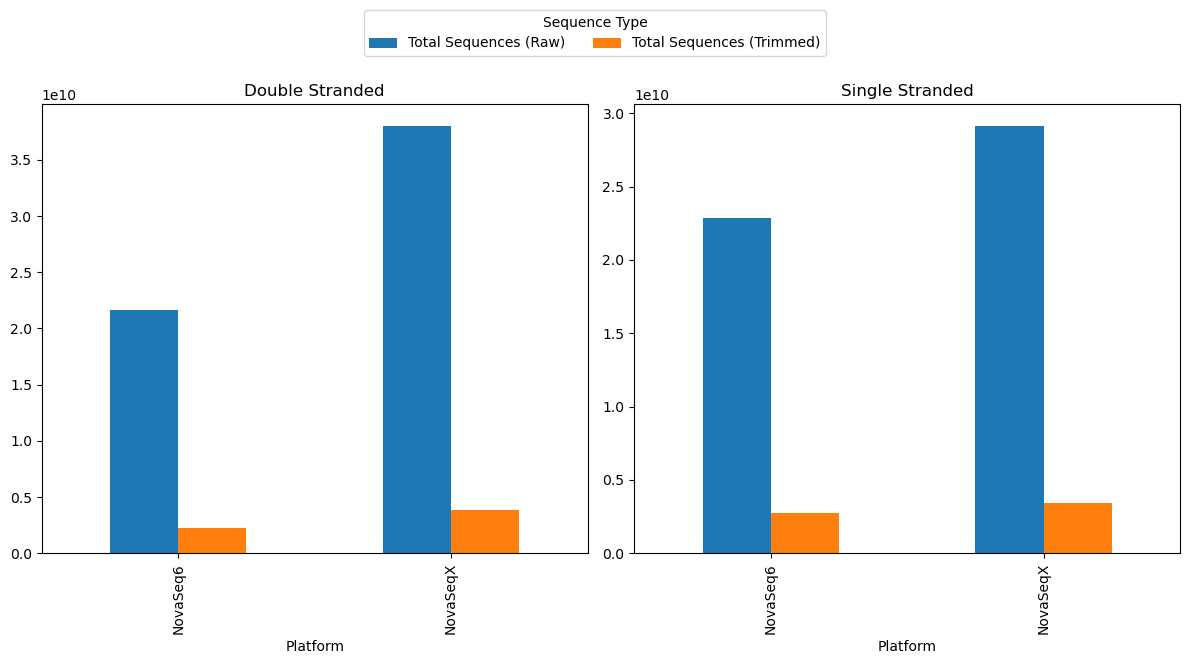

In [10]:
# Calculate mean values for each platform and each sequencing type
raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()

trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()

trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

# Combine data into a DataFrame for easier plotting
combined_sums_double = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_double,
    'Total Sequences (Trimmed)': trimmed_sum_double
})

# Combine data into a DataFrame for easier plotting
combined_sums_single = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_single,
    'Total Sequences (Trimmed)': trimmed_sum_single
})

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

plt.tight_layout()
plt.show()

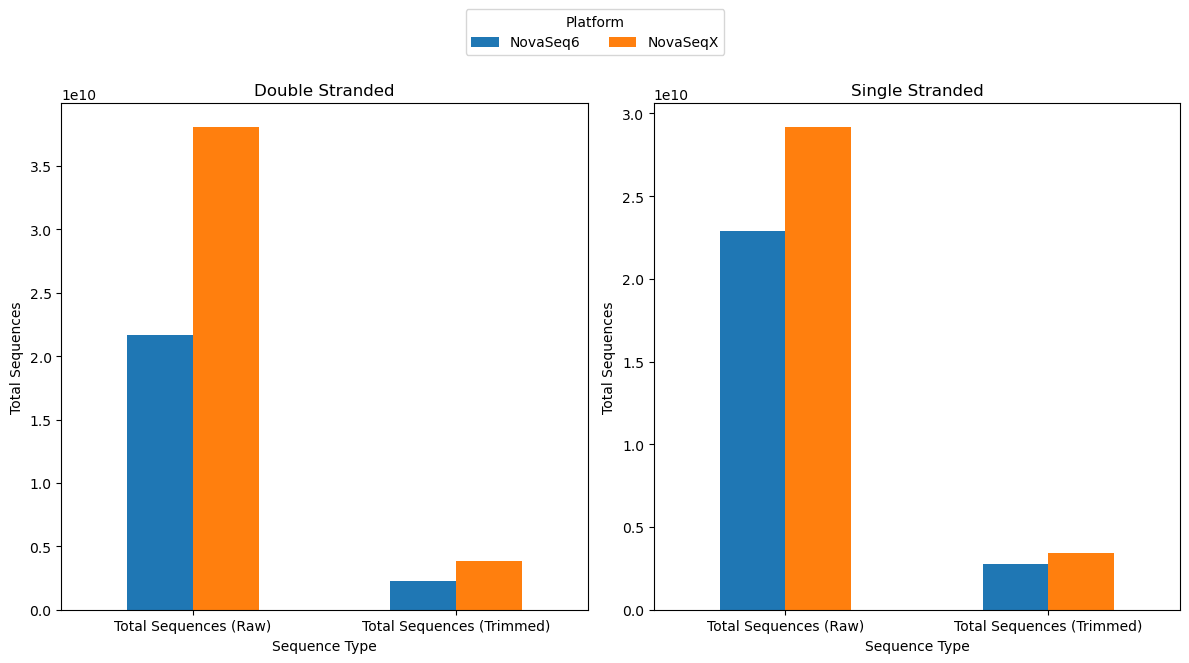

In [11]:

# Calculate mean values for each platform and each sequencing type
raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

# Combine data into a DataFrame for easier plotting
combined_sums_double = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_double,
    'Total Sequences (Trimmed)': trimmed_sum_double
}).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

combined_sums_single = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_single,
    'Total Sequences (Trimmed)': trimmed_sum_single
}).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Double Stranded
combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
ax[0].set_title("Double Stranded")
ax[0].set_ylabel("Total Sequences")

# Plot for Single Stranded
combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
ax[1].set_title("Single Stranded")
ax[1].set_ylabel("Total Sequences")

# Adding legend
handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

plt.tight_layout()
plt.show()

In [12]:
NovaSeq6

NameError: name 'NovaSeq6' is not defined

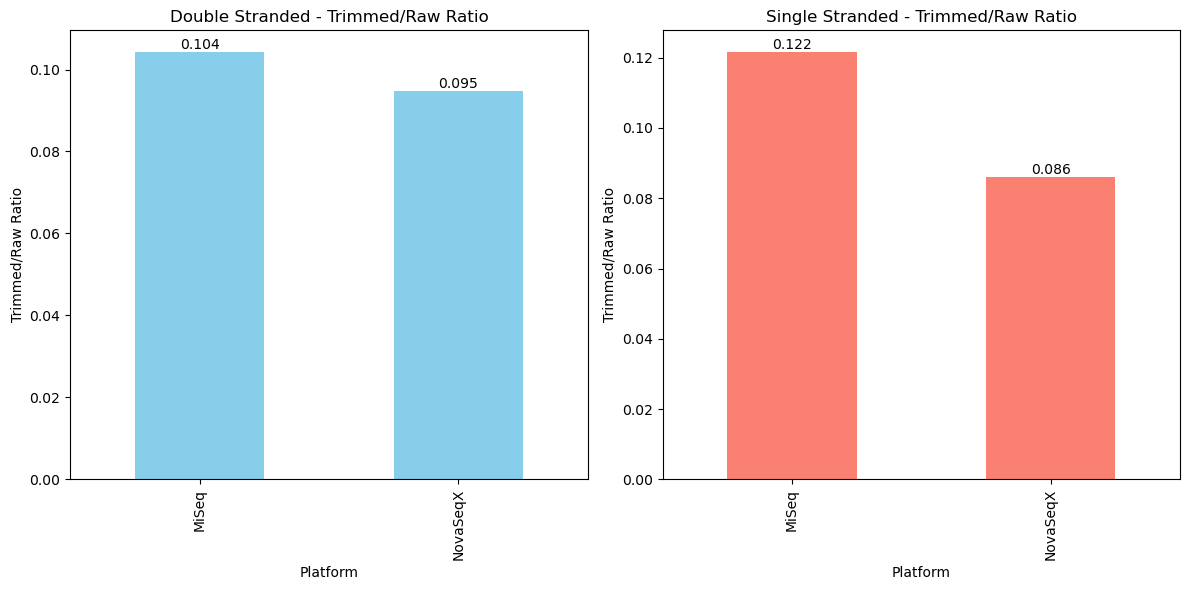

In [ ]:
# Calculate the ratio of trimmed to raw sequences
ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Double Stranded ratios
ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
ax[0].set_ylabel("Trimmed/Raw Ratio")
ax[0].set_xlabel("Platform")

# Annotate the bars with the ratio values
for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
    ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

# Plot for Single Stranded ratios
ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
ax[1].set_ylabel("Trimmed/Raw Ratio")
ax[1].set_xlabel("Platform")

# Annotate the bars with the ratio values
for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
    ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


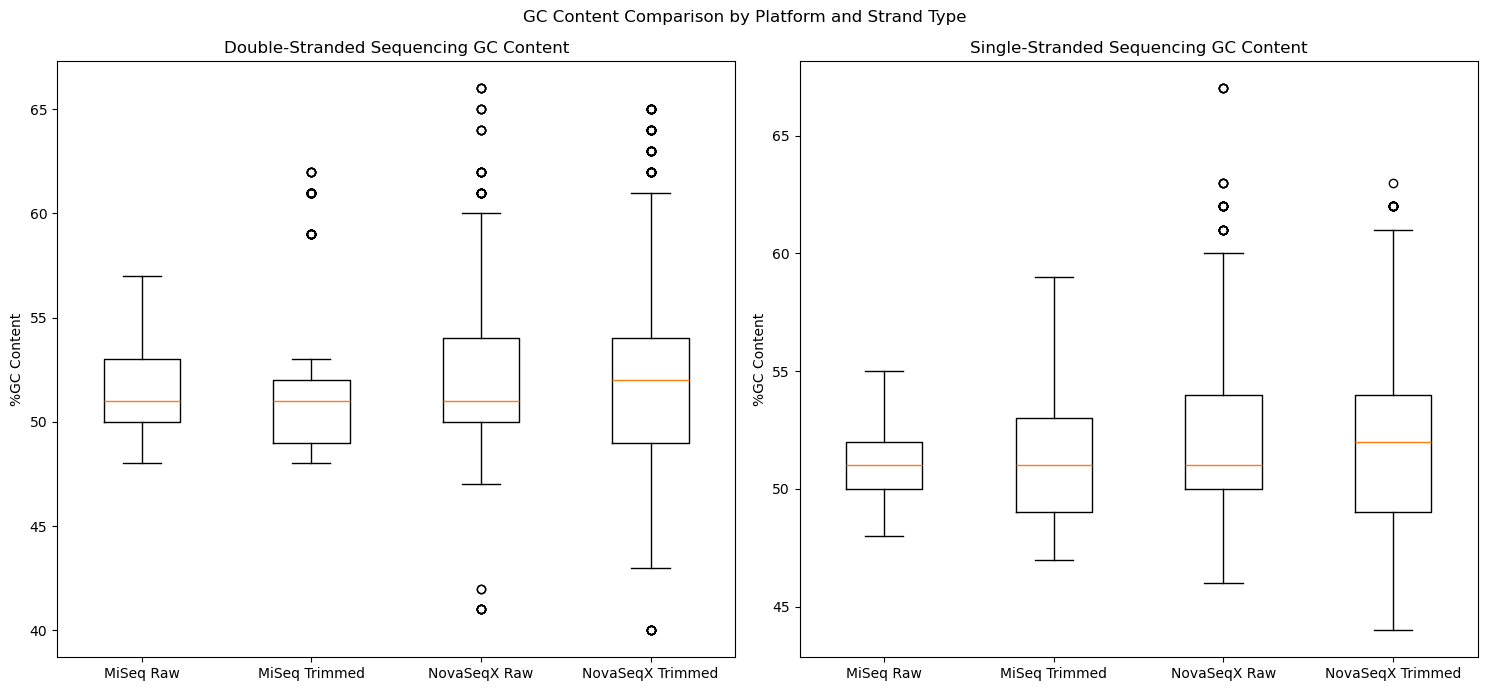

In [ ]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = [sequencer_1, sequencer_2]

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(double_df, describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(single_df, describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()

    

c:\Users\glj523\AppData\Local\miniconda3\envs\db_web_app\Lib\site-packages\pandas\plotting\_matplotlib\core.py:822: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  labels = axis.get_majorticklabels() + axis.get_minorticklabels()
c:\Users\glj523\AppData\Local\miniconda3\envs\db_web_app\Lib\site-packages\pandas\plotting\_matplotlib\core.py:822: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  labels = axis.get_majorticklabels() + axis.get_minorticklabels()


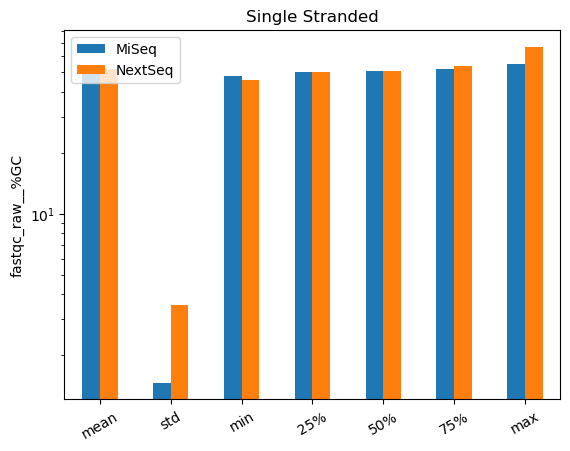

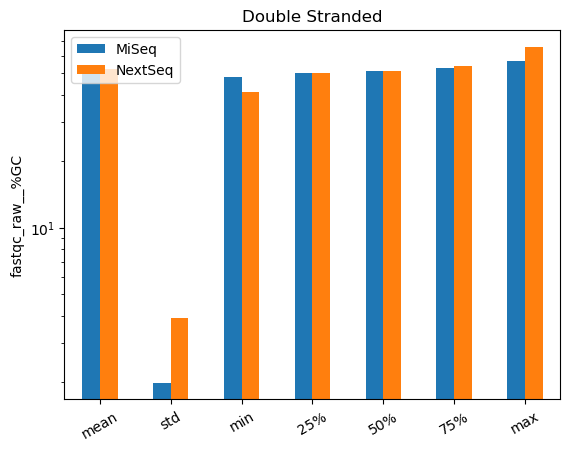

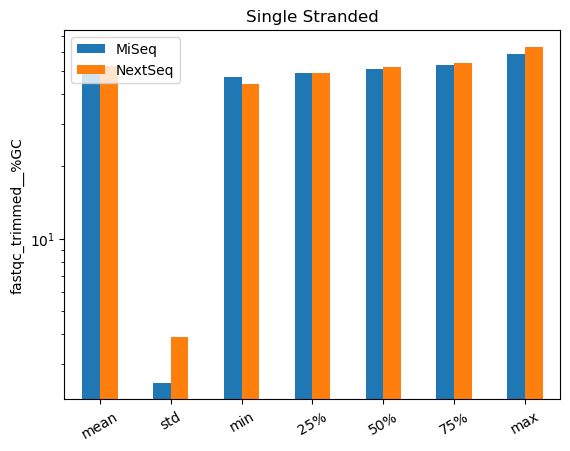

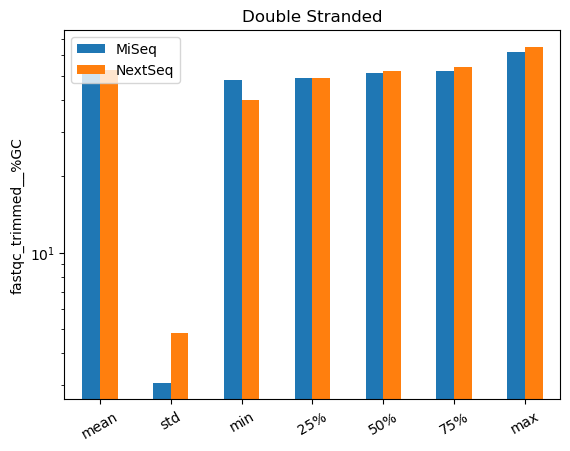

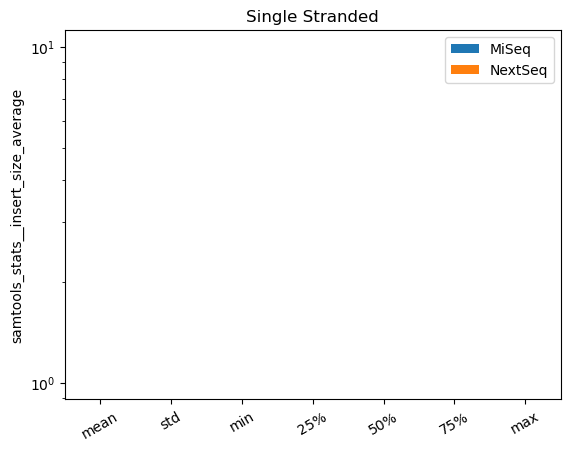

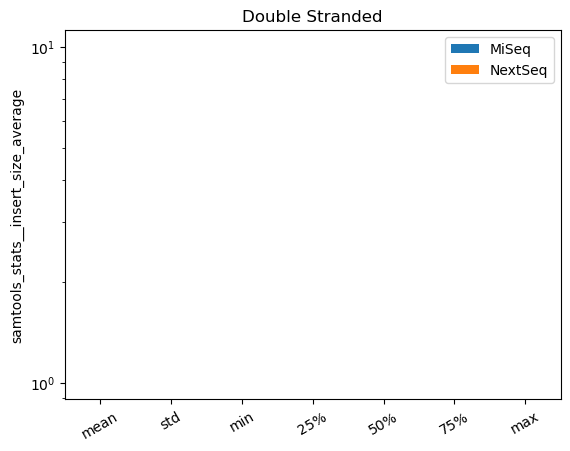

In [ ]:
def make_describe_plot(col, logy, data, include_count=False):
    for k, v in data.items():
        
        if include_count:
            data = {k: v[col].describe() for k, v in v.items()}
            
        else:
            data = {k: v[col].describe().iloc[1:] for k, v in v.items()}

        res = pd.DataFrame(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)


data = {"Single Stranded": {"MiSeq": datasets[1]["df"],
                            "NextSeq": datasets[3]["df"]},
        "Double Stranded": {"MiSeq": datasets[0]["df"],
                            "NextSeq": datasets[2]["df"]}
        }

datasets = [
    data_template(sequencer_1, "Double", n6_ds_qc),
    data_template(sequencer_1, "Single", n6_ss_qc),
    data_template(sequencer_2, "Double", nx_ds_qc),
    data_template(sequencer_2, "Single", nx_ss_qc),
]

for cols in describe_cols:

        make_describe_plot(cols, True, data, include_count=False)